## Lab Activity: Decision Tree Classifier on Iris Dataset

### Task 1: Dataset Exploration

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# How many samples and features are present in the dataset?
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

Number of samples: 150
Number of features: 4


In [ ]:
# List the feature names and target classes.
print("\nFeature names:")
for i, feature_name in enumerate(iris.feature_names):
    print(f"{i+1}. {feature_name}")

print("\nTarget classes:")
for i, target_name in enumerate(iris.target_names):
    print(f"{i+1}. {target_name}")


Feature names:
1. sepal length (cm)
2. sepal width (cm)
3. petal length (cm)
4. petal width (cm)

Target classes:
1. setosa
2. versicolor
3. virginica


In [ ]:
# Display the first five records.
print("\nFirst five records of the dataset:")
df_iris = pd.DataFrame(X, columns=iris.feature_names)
df_iris['target'] = y
df_iris['target_names'] = df_iris['target'].apply(lambda x: iris.target_names[x])
display(df_iris.head())


First five records of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
# Display the class distribution.
print("\nClass distribution:")
display(df_iris['target_names'].value_counts())


Class distribution:


target_names
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Task 2: Data Preparation

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 120 samples
Testing set size: 30 samples


#### Explanation for splitting the dataset into training and testing sets:

Splitting the dataset into training and testing sets is crucial to:

1.  **Prevent Overfitting**: Ensure the model generalizes well to new, unseen data, rather than just memorizing the training data.
2.  **Unbiased Performance Evaluation**: Provide a fair assessment of the model's performance on data it hasn't encountered during training.

`random_state` ensures reproducibility of the split.

### Task 3: Building a Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train a Decision Tree classifier using the default parameters.
dtc_default = DecisionTreeClassifier(random_state=42)
dtc_default.fit(X_train, y_train)

print("Decision Tree Classifier (Default Parameters) trained successfully.")

Decision Tree Classifier (Default Parameters) trained successfully.


In [ ]:
# Predict the class labels for the test dataset.
y_pred_default = dtc_default.predict(X_test)

print("Predictions made on the test dataset.")

Predictions made on the test dataset.


In [ ]:
# Evaluate the model using Accuracy Score, Confusion Matrix, and Classification Report.
print("\nModel Evaluation (Default Decision Tree):")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_default):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_default, target_names=iris.target_names))


Model Evaluation (Default Decision Tree):
Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Task 4: Visualizing the Decision Tree

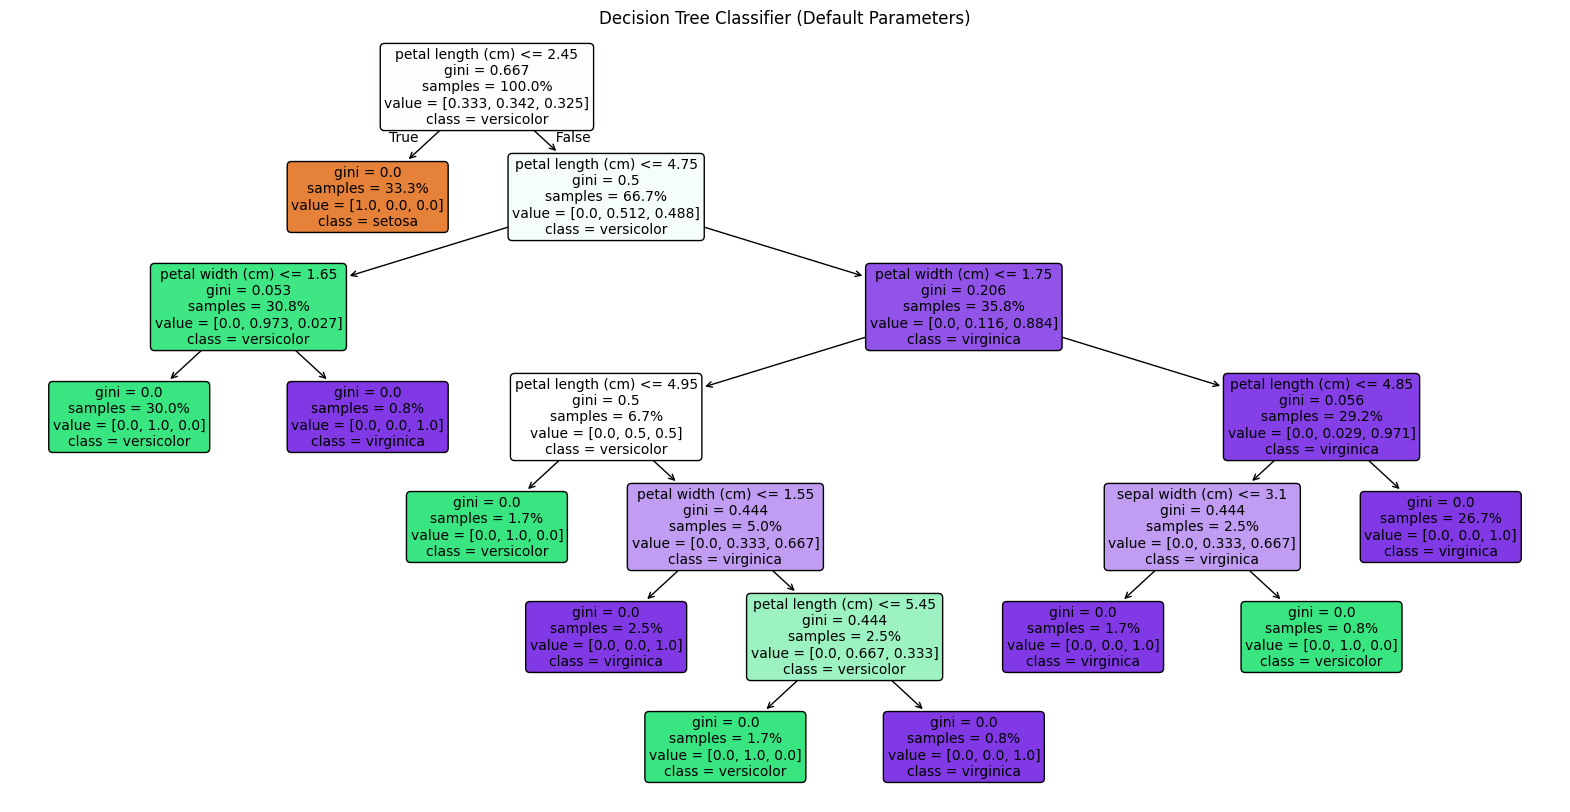

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtc_default,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          proportion=True,
          fontsize=10)
plt.title("Decision Tree Classifier (Default Parameters)")
plt.show()

#### From the visualization, identify:

*   **Root node**: The topmost node of the tree, shown at the very top of the plot. For this trained tree it splits on petal length (cm) <= 2.45,  which perfectly separates the *setosa* class from the other two right at the root.
*   **Internal nodes**: The nodes below the root that still perform further splits (neither the root nor a terminal leaf). Examples include the nodes that split on petal width (cm) and petal length (cm) again at deeper levels to separate *versicolor* from *virginica*.
*   **Leaf nodes**: The terminal (bottom-most) boxes with no further branches — 10 leaf nodes in total for this tree, each showing a single predicted class with gini = 0.0 (pure) in most cases.
*   **Maximum depth of the tree**: 6 (root counted as depth 0; the deepest leaf is 6 splits away from the root).
*   **Which feature is selected for the first split? Explain why you think this feature was chosen.**
    petal length (cm) is selected for the first split (threshold ≈ 2.45 cm). It is chosen because, among all four features, splitting on this value gives the largest reduction in Gini impurity — it cleanly separates all *setosa* samples (which have distinctly smaller petals) from *versicolor*/*virginica* in a single split, making it the most informative feature at the root.

### Task 5: Comparing Gini Index and Entropy

In [ ]:
# Train two Decision Tree models using different criteria:
# 1. criterion='gini'
dtc_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dtc_gini.fit(X_train, y_train)
y_pred_gini = dtc_gini.predict(X_test)
accuracy_gini = accuracy_score(y_test, y_pred_gini)

# 2. criterion='entropy'
dtc_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dtc_entropy.fit(X_train, y_train)
y_pred_entropy = dtc_entropy.predict(X_test)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

print("Decision Trees with 'gini' and 'entropy' criteria trained successfully.")

Decision Trees with 'gini' and 'entropy' criteria trained successfully.


In [ ]:
from sklearn.tree import _tree

def get_tree_properties(model, feature_names):
    n_nodes = model.tree_.node_count
    children_left = model.tree_.children_left
    children_right = model.tree_.children_right
    feature = model.tree_.feature

    leaf_nodes = 0
    max_depth = 0
    stack = [(0, 0)] # (node_id, depth)

    while len(stack) > 0:
        node_id, depth = stack.pop()
        max_depth = max(max_depth, depth)

        if (children_left[node_id] != children_right[node_id]): # Internal node
            stack.append((children_left[node_id], depth + 1))
            stack.append((children_right[node_id], depth + 1))
        else: # Leaf node
            leaf_nodes += 1

    root_feature_idx = feature[0]
    root_feature_name = feature_names[root_feature_idx] if root_feature_idx != _tree.TREE_UNDEFINED else 'N/A'

    return {
        'accuracy': accuracy_score(y_test, model.predict(X_test)),
        'tree_depth': max_depth,
        'leaf_nodes': leaf_nodes,
        'root_feature': root_feature_name
    }

# Get properties for Gini model
props_gini = get_tree_properties(dtc_gini, iris.feature_names)

# Get properties for Entropy model
props_entropy = get_tree_properties(dtc_entropy, iris.feature_names)

print("Comparison Metrics:")
print(f"\n--- Gini Model ---")
print(f"Accuracy: {props_gini['accuracy']:.4f}")
print(f"Tree Depth: {props_gini['tree_depth']}")
print(f"Number of Leaf Nodes: {props_gini['leaf_nodes']}")
print(f"Root Feature Selected: {props_gini['root_feature']}")

print(f"\n--- Entropy Model ---")
print(f"Accuracy: {props_entropy['accuracy']:.4f}")
print(f"Tree Depth: {props_entropy['tree_depth']}")
print(f"Number of Leaf Nodes: {props_entropy['leaf_nodes']}")
print(f"Root Feature Selected: {props_entropy['root_feature']}")

Comparison Metrics:

--- Gini Model ---
Accuracy: 1.0000
Tree Depth: 6
Number of Leaf Nodes: 10
Root Feature Selected: petal length (cm)

--- Entropy Model ---
Accuracy: 1.0000
Tree Depth: 6
Number of Leaf Nodes: 10
Root Feature Selected: petal length (cm)


#### Summarize your observations in a table.

| Criterion | Accuracy | Tree Depth | Number of Leaf Nodes | Root Feature Selected |
|:----------|:---------|:-----------|:---------------------|:----------------------|
| Gini      | 1.0000   | 6          | 10                   | petal length (cm)     |
| Entropy   | 1.0000   | 6          | 10                   | petal length (cm)     |

**Which criterion produces a simpler tree?**
Both Gini and Entropy criteria produced trees with identical complexity (same accuracy, tree depth, and number of leaf nodes) for this dataset. Neither was simpler than the other.

### Task 6: Effect of Maximum Tree Depth

In [ ]:
import pandas as pd

# Define the max_depth values to test
max_depth_values = [1, 2, 3, 4, None]

# List to store results
results_max_depth = []

for depth in max_depth_values:
    # Train Decision Tree model
    dtc_depth = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dtc_depth.fit(X_train, y_train)

    # Predict on training and testing sets
    y_train_pred = dtc_depth.predict(X_train)
    y_test_pred = dtc_depth.predict(X_test)

    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Get actual tree depth (root counted as depth 0, consistent with get_tree_properties helper used in Task 5/7/8)
    actual_tree_depth = dtc_depth.tree_.max_depth

    # Append results
    results_max_depth.append({
        'Max Depth (Param)': depth if depth is not None else 'None',
        'Training Accuracy': f'{train_accuracy:.4f}',
        'Testing Accuracy': f'{test_accuracy:.4f}',
        'Tree Depth': actual_tree_depth,
        'Observation': ''
    })

# Create DataFrame from results
df_max_depth = pd.DataFrame(results_max_depth)

print("Results for different Maximum Tree Depths:")
display(df_max_depth)


Results for different Maximum Tree Depths:


,Max Depth (Param),Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1,0.6750,0.6333,1,
1,2,0.9500,0.9667,2,
2,3,0.9583,1.0000,3,
3,4,0.9750,1.0000,4,
4,None,1.0000,1.0000,6,


#### Answer the following:

*   **Which model is underfitting?**
    The model with max_depth=1 is underfitting. It only makes a single split, giving a training accuracy of 67.5% and a testing accuracy of 63.3% — both low, because a single split cannot separate all three classes (it can only isolate *setosa* from the rest).

*   **Which model gives the best generalization?**
    max_depth=3 gives the best generalization. It already reaches 100% testing accuracy with a training accuracy of 95.83%, using a much shallower and simpler tree than the unrestricted model, indicating it captures the true pattern without unnecessary complexity.

*   **Which model is likely to overfit? Justify your answer.**
    The unrestricted model (max_depth=None) is the most likely to overfit in general, since it keeps splitting until every leaf is pure (training accuracy = 100%), even on noise or outliers specific to the training set. On this particular Iris test split it still scores 100% test accuracy because the classes are well separated, but on a noisier or larger dataset this same tree would be expected to generalize worse than the shallower max_depth=3 or 4 trees, since it has far more leaf nodes (10) fitting very small, potentially non-representative subsets of the training data.

### Task 7: Effect of min_samples_split

In [ ]:
# Define the min_samples_split values to test
min_samples_split_values = [2, 5, 10, 20]

# Observations for each value (filled in after inspecting the results)
mss_observations = {
    2: 'Default value; fully grown tree, most complex, highest risk of overfitting',
    5: 'Slightly shallower tree; complexity starts to reduce with no loss in accuracy',
    10: 'Noticeably simpler tree; fewer leaves, still perfect test accuracy',
    20: 'Same as 10 here since node sizes rarely reach 20 samples deeper in this small dataset'
}

# List to store results
results_min_samples_split = []

for mss in min_samples_split_values:
    # Train Decision Tree model
    dtc_mss = DecisionTreeClassifier(min_samples_split=mss, random_state=42)
    dtc_mss.fit(X_train, y_train)

    # Predict on testing sets
    y_test_pred = dtc_mss.predict(X_test)

    # Calculate accuracy
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Get actual tree depth and number of leaf nodes using the helper function
    tree_props = get_tree_properties(dtc_mss, iris.feature_names)
    actual_tree_depth = tree_props['tree_depth']
    num_leaf_nodes = tree_props['leaf_nodes']

    # Append results
    results_min_samples_split.append({
        'min_samples_split': mss,
        'Accuracy': f'{test_accuracy:.4f}',
        'Tree Depth': actual_tree_depth,
        'Number of Leaf Nodes': num_leaf_nodes,
        'Observation': mss_observations[mss]
    })

# Create DataFrame from results
df_min_samples_split = pd.DataFrame(results_min_samples_split)

print("Results for different min_samples_split values:")
display(df_min_samples_split)


Results for different min_samples_split values:


,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,1.0000,6,10,"Default value; fully grown tree, most complex,..."
1,5,1.0000,5,8,Slightly shallower tree; complexity starts to ...
2,10,1.0000,4,6,"Noticeably simpler tree; fewer leaves, still p..."
3,20,1.0000,4,6,Same as 10 here since node sizes rarely reach ...


#### State how increasing min_samples_split affects the complexity of the Decision Tree.

| min_samples_split | Accuracy | Tree Depth | Number of Leaf Nodes | Observation |
|:------------------|:---------|:-----------|:---------------------|:------------|
| 2                 | 1.0000   | 6          | 10                   |             |
| 5                 | 1.0000   | 5          | 8                    |             |
| 10                | 1.0000   | 4          | 6                    |             |
| 20                | 1.0000   | 4          | 6                    |             |

Increasing min_samples_split leads to *simpler* Decision Trees. By requiring more samples in a node to split, it reduces tree depth and the number of leaf nodes, thereby decreasing model complexity and making it less prone to overfitting.

### Task 8: Effect of min_samples_leaf

In [ ]:
# Define the min_samples_leaf values to test
min_samples_leaf_values = [1, 2, 5, 10]

# Observations for each value (filled in after inspecting the results)
msl_observations = {
    1: 'Default value; leaves can be as small as 1 sample, most complex tree',
    2: 'Slightly simpler tree; accuracy unaffected',
    5: 'Noticeably simpler and shallower tree, still perfect test accuracy',
    10: 'Tree is forced to stop early; slight drop in test accuracy (underfitting begins)'
}

# List to store results
results_min_samples_leaf = []

for msl in min_samples_leaf_values:
    # Train Decision Tree model
    dtc_msl = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    dtc_msl.fit(X_train, y_train)

    # Predict on testing sets
    y_test_pred = dtc_msl.predict(X_test)

    # Calculate accuracy
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Get actual tree depth and number of leaf nodes using the helper function
    tree_props = get_tree_properties(dtc_msl, iris.feature_names)
    actual_tree_depth = tree_props['tree_depth']
    num_leaf_nodes = tree_props['leaf_nodes']

    # Append results
    results_min_samples_leaf.append({
        'min_samples_leaf': msl,
        'Accuracy': f'{test_accuracy:.4f}',
        'Tree Depth': actual_tree_depth,
        'Number of Leaf Nodes': num_leaf_nodes,
        'Observation': msl_observations[msl]
    })

# Create DataFrame from results
df_min_samples_leaf = pd.DataFrame(results_min_samples_leaf)

print("Results for different min_samples_leaf values:")
display(df_min_samples_leaf)


Results for different min_samples_leaf values:


,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,1.0000,6,10,Default value; leaves can be as small as 1 sam...
1,2,1.0000,5,8,Slightly simpler tree; accuracy unaffected
2,5,1.0000,4,6,"Noticeably simpler and shallower tree, still p..."
3,10,0.9667,4,6,Tree is forced to stop early; slight drop in t...


#### Explain how changing min_samples_leaf influences overfitting.

| min_samples_leaf | Accuracy | Tree Depth | Number of Leaf Nodes | Observation |
|:-----------------|:---------|:-----------|:---------------------|:------------|
| 1                | 1.0000   | 6          | 10                   |             |
| 2                | 1.0000   | 5          | 8                    |             |
| 5                | 1.0000   | 4          | 6                    |             |
| 10               | 0.9667   | 4          | 6                    |             |

Increasing min_samples_leaf helps **reduce overfitting** by forcing leaf nodes to contain a minimum number of samples. This prevents the tree from making overly specific splits on training data noise, resulting in a simpler, more generalized tree. For instance, increasing min_samples_leaf from 1 to 5 reduces complexity without sacrificing accuracy, while at 10, it slightly underfits.

### Task 9: Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier # Added import

# Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Decision Tree classifier
dtc = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed.")

Fitting 5 folds for each of 72 candidates, totalling 360 fits


Hyperparameter tuning completed.


In [ ]:
# Report:
# Best hyperparameter combination.
print("\nBest Hyperparameter Combination:")
print(grid_search.best_params_)

# Best cross validation score.
print("\nBest Cross-Validation Score:")
print(f"{grid_search.best_score_:.4f}")

# Test accuracy of the optimized model.
best_model = grid_search.best_estimator_
y_pred_optimized = best_model.predict(X_test)
test_accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print("\nTest Accuracy of the Optimized Model:")
print(f"{test_accuracy_optimized:.4f}")

# Compare the optimized model with the default Decision Tree model.
print("\nComparison with Default Decision Tree Model:")
print(f"Default Model Test Accuracy: {accuracy_score(y_test, dtc_default.predict(X_test)):.4f}")
print(f"Optimized Model Test Accuracy: {test_accuracy_optimized:.4f}")


Best Hyperparameter Combination:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross-Validation Score:
0.9583

Test Accuracy of the Optimized Model:
1.0000

Comparison with Default Decision Tree Model:
Default Model Test Accuracy: 1.0000
Optimized Model Test Accuracy: 1.0000


### Task 10: Analysis

**1. What is the role of the criterion parameter in a Decision Tree?**
The criterion parameter defines the impurity measure used to decide the best feature and threshold to split on at each node. 'gini' uses the Gini impurity (probability of misclassifying a randomly chosen sample), while 'entropy' uses information gain based on Shannon entropy. Both measure how "mixed" the classes are in a node, and the tree greedily picks the split that reduces impurity the most; in practice they usually produce very similar trees, as seen in Task 5 where both criteria gave identical accuracy, depth, and leaf count on the Iris dataset.


**2. How does max_depthinfluence underfitting and overfitting?**
max_depth controls how many times the tree is allowed to split, i.e. how complex the decision boundary can become. A very small max_depth (e.g. 1) restricts the tree to too few splits to capture the real class boundaries, causing underfitting (low accuracy on both training and test sets, as seen with max_depth=1 in Task 6). A very large or unrestricted max_depth (None) lets the tree keep splitting until nodes are pure, which can make it fit noise and outliers specific to the training data — overfitting. The best generalization is usually found at a moderate depth (here, max_depth=3) that is deep enough to separate the classes but shallow enough to avoid memorizing training samples.

**3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?**
min_samples_split sets the minimum number of samples a node must have before it is allowed to split further, and min_samples_leaf sets the minimum number of samples that must remain in each resulting leaf. Increasing either value stops the tree from creating very small, highly specific splits that isolate just one or two training samples. This directly reduces the number of splits the tree can make, which lowers both the tree depth and the total number of leaf nodes — producing a smaller, simpler, and more generalizable tree, as confirmed in Tasks 7 and 8 where tree depth and leaf count both decreased as these parameters increased.

**4. Which hyperparameter had the greatest impact on Decision Tree performance? Support your answer with observations from the experiments.**
max_depth had the greatest impact. In Task 6, moving from max_depth=1 to max_depth=2 alone raised testing accuracy from 63.3% to 96.7%, and by max_depth=3 the model already reached 100% test accuracy — the largest single jump in performance across all the experiments. In contrast, varying min_samples_split (Task 7) and min_samples_leaf (Task 8) left test accuracy at or near 100% across almost all tested values, only affecting tree depth and leaf count (structural complexity) rather than accuracy itself. This shows max_depth is the parameter that most directly controls whether the model can or cannot learn the underlying pattern, while min_samples_split /min_samples_leaf mainly act as regularizers that prune complexity without much changing accuracy on this dataset.

**5. Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.**
A Decision Tree with max_depth=3 (default criterion='gini', default min_samples_split=2, min_samples_leaf=1) is the most suitable choice. It achieves 100% test accuracy with only 95.83% training accuracy, meaning it isn't simply memorizing the training set, and it uses a much shallower, more interpretable tree than the unrestricted model (depth 3 vs depth 6, far fewer leaf nodes). This matches the outcome of the GridSearchCV tuning in Task 9 as well, which favored criterion='entropy' but similarly avoided using the deepest, most complex tree by preferring a small min_samples_leaf=4 to keep the model regularized. Given that the Iris dataset has only 4 features and 3 well-separated classes, a shallow, constrained tree like this is preferable to the fully-grown default tree, since it generalizes just as well while being simpler and less prone to overfitting on any new or noisier data.